In [1]:
import numpy as np
import roboticstoolbox as rtb
import spatialmath as sm
import matplotlib.pyplot as plt

Definicion del robot

In [2]:
#Definicion en mm
irb140 = rtb.DHRobot(
    [
        rtb.RevoluteDH(alpha=-np.pi/2,a=70),
        rtb.RevoluteDH(a=360),
        rtb.RevoluteDH(alpha=np.pi/2),
        rtb.RevoluteDH(d=380, alpha=-np.pi/2),
        #rtb.RevoluteDH(alpha=np.pi/2),
        #rtb.RevoluteDH()
    ], name="IRB140")

#Velocidades de rotacion maximas
q_dot_max = np.radians(np.array([200, 200, 260, np.inf])) #rad/s

In [ ]:
def calcular_v_max_constante(z_prueba, y_plano=100):
    x_puntos = np.linspace(-100, 100, 50)
    v_max_puntos = []

    for x in x_puntos:
        T = sm.SE3.Trans(x, y_plano, z_prueba)
        
        # Resolvemos IK para los 4 ejes. 
        # El 4to eje suele quedar en 0 si no se pide orientación.
        sol = irb140.ikine_LM(T, mask=[1, 1, 1, 0, 0, 0]) #Mask ignora las rotaciones
        
        if not sol.success:
            return 0
        
        # Jacobiano de traslación (3 filas x 4 columnas)
        # Nos dice cómo afectan los 4 motores a la posición (x, y, z)
        J_full = irb140.jacob0(sol.q)[:3, :]
        
        # Como solo usamos los motores 1, 2 y 3 para la tarea, 
        # tomamos las primeras 3 columnas del Jacobiano.
        J = J_full[:, :3] 
        
        try:
            J_inv = np.linalg.inv(J)
            direccion_x = np.array([1, 0, 0])
            ratio_velocidad = np.abs(J_inv @ direccion_x)
            
            # Solo evaluamos el límite de los primeros 3 motores
            v_permitida_motores = q_dot_max[:3] / ratio_velocidad
            v_max_puntos.append(np.min(v_permitida_motores))
            
        except np.linalg.LinAlgError:
            return 0

    return np.min(v_max_puntos) if v_max_puntos else 0

# 3. Barrido de optimización
z_rango = np.linspace(0, 1000, 100) # Probamos alturas desde la base hacia arriba
resultados_v = [calcular_v_max_constante(z, y_plano = 500) for z in z_rango]

idx_optimo = np.argmax(resultados_v)
print(f"Resultado para trayectoria de 200mm en plano y cte:")
print(f"Z óptimo: {z_rango[idx_optimo]:.2f} mm")
print(f"Velocidad máxima constante: {resultados_v[idx_optimo]:.2f} mm/s")

Resultado para trayectoria de 200mm en plano y cte:
Z óptimo: 290.91 mm
Velocidad máxima constante: 1745.36 mm/s


[1745.3583286998328, 1745.3583286999014, 1745.3583286999021, 1745.3583286999026, 1745.3583286999021, 1745.3583286956728, 1745.3583286955527, 1745.3583286998976, 1745.3583286999026, 1745.358328695745, 1745.3583286999026, 1745.3583286999026, 1745.3583286998635, 1745.3583286998826, 1745.3583286999017, 1745.3583286985017, 1745.3583286999026, 1745.3583286974992, 1745.358328699711, 1745.358328699888, 1745.35832869646, 1745.3583286998987, 1745.3583286999014, 1745.3583286998794, 1745.3583286946619, 1745.3583286998896, 1745.3583286998771, 1745.3583286999021, 1745.3583286997928, 1745.3583286998994, 1745.3583286999021, 1745.358328699702, 1745.3583286999021, 1745.3583286999026, 1745.3583286999005, 1745.3583286990465, 1745.3583286998416, 1745.3583286999021, 1745.3583286998662, 1745.358328699901, 1745.3583286998753, 1745.3583286999021, 1745.3583286998764, 1745.3583286923524, 1745.3583286999026, 1745.3583286999026, 1745.3583286999021, 1745.3583286916148, 1745.3583286999028, 1745.3583286969747, 1745.3

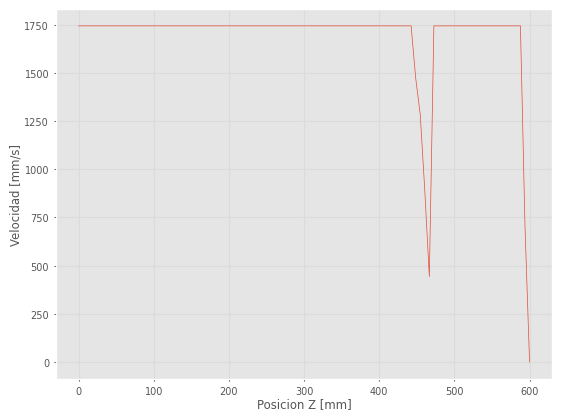

In [9]:
plt.figure()
plt.plot(z_rango, resultados_v)
plt.ylabel("Velocidad [mm/s]")
plt.xlabel("Posicion Z [mm]")
print(resultados_v)